In [6]:
from google.colab import files

uploaded = files.upload()


Saving cookie_cats.csv.zip to cookie_cats.csv (2).zip


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import zipfile
import os

# Find the uploaded ZIP file
zip_file = [f for f in os.listdir() if f.endswith(".zip")][0]

print("ZIP file found:", zip_file)

# Extract the ZIP file
with zipfile.ZipFile(zip_file, 'r') as zip_ref:
    zip_ref.extractall("data")

# See what was extracted
print("Files extracted:")
print(os.listdir("data"))


ZIP file found: cookie_cats.csv.zip
Files extracted:
['cookie_cats.csv']


In [7]:
# Find the CSV file inside the data folder
csv_file = [f for f in os.listdir("data") if f.endswith(".csv")][0]

print("CSV file:", csv_file)

# Load dataset
df = pd.read_csv("data/" + csv_file)

# Display first 5 rows
df.head()

CSV file: cookie_cats.csv


,userid,version,sum_gamerounds,retention_1,retention_7
0,116,gate_30,3,False,False
1,337,gate_30,38,True,False
2,377,gate_40,165,True,False
3,483,gate_40,1,False,False
4,488,gate_40,179,True,True


In [8]:
print("Dataset shape:", df.shape)

print("\n--- Columns ---")
print(df.columns.tolist())

print("\n--- Missing values ---")
print(df.isnull().sum())

print("\n--- Duplicate rows ---")
print(df.duplicated().sum())

print("\n--- Unique users ---")
print(df["userid"].nunique())

print("\n--- Experiment groups ---")
print(df["version"].value_counts())

Dataset shape: (90189, 5)

--- Columns ---
['userid', 'version', 'sum_gamerounds', 'retention_1', 'retention_7']

--- Missing values ---
userid            0
version           0
sum_gamerounds    0
retention_1       0
retention_7       0
dtype: int64

--- Duplicate rows ---
0

--- Unique users ---
90189

--- Experiment groups ---
version
gate_40    45489
gate_30    44700
Name: count, dtype: int64


In [9]:
print("Average game rounds:", df["sum_gamerounds"].mean())
print("Median game rounds:", df["sum_gamerounds"].median())
print("Maximum game rounds:", df["sum_gamerounds"].max())

Average game rounds: 51.8724567297564
Median game rounds: 16.0
Maximum game rounds: 49854


In [10]:
engagement = df.groupby("version")["sum_gamerounds"].agg(
    ["count", "mean", "median", "min", "max"]
)

engagement

,count,mean,median,min,max
version,,,,,
gate_30,44700,52.456264,17.0,0,49854
gate_40,45489,51.298776,16.0,0,2640


In [11]:
gate30_mean = df[df["version"] == "gate_30"]["sum_gamerounds"].mean()
gate40_mean = df[df["version"] == "gate_40"]["sum_gamerounds"].mean()

difference = gate40_mean - gate30_mean
percentage_difference = (difference / gate30_mean) * 100

print("Gate 30 average:", gate30_mean)
print("Gate 40 average:", gate40_mean)
print("Difference:", difference)
print("Percentage difference:", percentage_difference, "%")

Gate 30 average: 52.45626398210291
Gate 40 average: 51.29877552814966
Difference: -1.157488453953249
Percentage difference: -2.2065781397397313 %


In [12]:
# Calculate Day-1 and Day-7 retention by experiment group

retention = df.groupby("version")[["retention_1", "retention_7"]].mean()

# Convert to percentages
retention_percentage = retention * 100

retention_percentage

,retention_1,retention_7
version,,
gate_30,44.818792,19.020134
gate_40,44.228275,18.200004


In [13]:
gate30_day1 = df[df["version"] == "gate_30"]["retention_1"].mean() * 100
gate40_day1 = df[df["version"] == "gate_40"]["retention_1"].mean() * 100

gate30_day7 = df[df["version"] == "gate_30"]["retention_7"].mean() * 100
gate40_day7 = df[df["version"] == "gate_40"]["retention_7"].mean() * 100

print("Day-1 Retention")
print("Gate 30:", round(gate30_day1, 2), "%")
print("Gate 40:", round(gate40_day1, 2), "%")
print("Difference:", round(gate40_day1 - gate30_day1, 2), "percentage points")

print("\nDay-7 Retention")
print("Gate 30:", round(gate30_day7, 2), "%")
print("Gate 40:", round(gate40_day7, 2), "%")
print("Difference:", round(gate40_day7 - gate30_day7, 2), "percentage points")

Day-1 Retention
Gate 30: 44.82 %
Gate 40: 44.23 %
Difference: -0.59 percentage points

Day-7 Retention
Gate 30: 19.02 %
Gate 40: 18.2 %
Difference: -0.82 percentage points


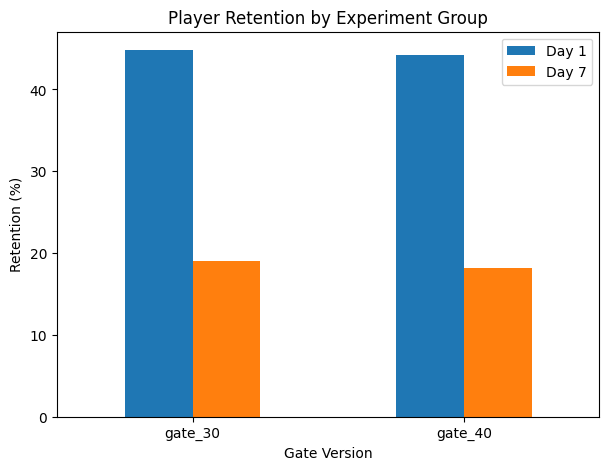

In [14]:
retention_percentage.plot(
    kind="bar",
    figsize=(7, 5)
)

plt.title("Player Retention by Experiment Group")
plt.xlabel("Gate Version")
plt.ylabel("Retention (%)")
plt.xticks(rotation=0)
plt.legend(["Day 1", "Day 7"])
plt.show()

In [15]:
import sqlite3

# Create SQLite database
conn = sqlite3.connect("mobile_game.db")

# Store our dataframe as a SQL table
df.to_sql("players", conn, if_exists="replace", index=False)

print("Database created successfully!")

Database created successfully!


In [16]:
pd.read_sql("SELECT * FROM players LIMIT 5;", conn)

,userid,version,sum_gamerounds,retention_1,retention_7
0,116,gate_30,3,0,0
1,337,gate_30,38,1,0
2,377,gate_40,165,1,0
3,483,gate_40,1,0,0
4,488,gate_40,179,1,1


In [17]:
query = """
SELECT
    version,
    COUNT(*) AS total_players
FROM players
GROUP BY version;
"""

pd.read_sql(query, conn)


,version,total_players
0,gate_30,44700
1,gate_40,45489


In [18]:
query = """
SELECT
    version,
    COUNT(*) AS total_players,
    ROUND(AVG(sum_gamerounds), 2) AS avg_game_rounds
FROM players
GROUP BY version;
"""

pd.read_sql(query, conn)

,version,total_players,avg_game_rounds
0,gate_30,44700,52.46
1,gate_40,45489,51.30


In [19]:
query = """
SELECT
    version,
    ROUND(AVG(CASE WHEN retention_1 = 1 THEN 1.0 ELSE 0 END) * 100, 2)
        AS day1_retention,
    ROUND(AVG(CASE WHEN retention_7 = 1 THEN 1.0 ELSE 0 END) * 100, 2)
        AS day7_retention
FROM players
GROUP BY version;
"""

pd.read_sql(query, conn)

,version,day1_retention,day7_retention
0,gate_30,44.82,19.02
1,gate_40,44.23,18.20


In [20]:
def engagement_segment(rounds):
    if rounds <= 10:
        return "Low"
    elif rounds <= 100:
        return "Medium"
    else:
        return "High"

df["engagement_segment"] = df["sum_gamerounds"].apply(engagement_segment)

df.head()

,userid,version,sum_gamerounds,retention_1,retention_7,engagement_segment
0,116,gate_30,3,False,False,Low
1,337,gate_30,38,True,False,Medium
2,377,gate_40,165,True,False,High
3,483,gate_40,1,False,False,Low
4,488,gate_40,179,True,True,High


In [21]:
df["engagement_segment"].value_counts()

,count
engagement_segment,
Medium,41815
Low,35989
High,12385


In [22]:
segment_analysis = pd.crosstab(
    df["version"],
    df["engagement_segment"],
    normalize="index"
) * 100

segment_analysis.round(2)

engagement_segment,High,Low,Medium
version,,,
gate_30,13.64,39.54,46.83
gate_40,13.83,40.26,45.91


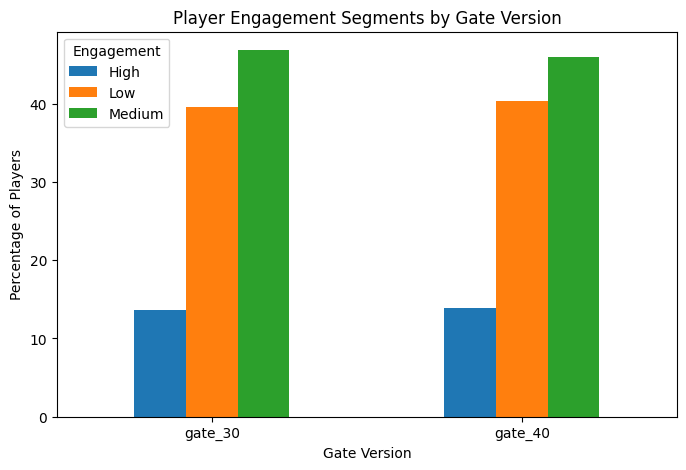

In [23]:
segment_analysis.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Player Engagement Segments by Gate Version")
plt.xlabel("Gate Version")
plt.ylabel("Percentage of Players")
plt.xticks(rotation=0)
plt.legend(title="Engagement")
plt.show()

In [27]:
query = """
SELECT
    version,
    CASE
        WHEN sum_gamerounds <= 10 THEN 'Low'
        WHEN sum_gamerounds <= 100 THEN 'Medium'
        ELSE 'High'
    END AS engagement_segment,
    COUNT(*) AS players
FROM players
GROUP BY
    version,
    engagement_segment
ORDER BY
    version,
    players DESC;
"""

pd.read_sql(query, conn)


,version,engagement_segment,players
0,gate_30,Medium,20932
1,gate_30,Low,17673
2,gate_30,High,6095
3,gate_40,Medium,20883
4,gate_40,Low,18316
5,gate_40,High,6290


In [28]:
query = """
SELECT
    version,
    CASE
        WHEN sum_gamerounds <= 10 THEN 'Low'
        WHEN sum_gamerounds <= 100 THEN 'Medium'
        ELSE 'High'
    END AS engagement_segment,
    COUNT(*) AS players
FROM players
GROUP BY version, engagement_segment
ORDER BY version, players DESC;
"""

pd.read_sql(query, conn)

,version,engagement_segment,players
0,gate_30,Medium,20932
1,gate_30,Low,17673
2,gate_30,High,6095
3,gate_40,Medium,20883
4,gate_40,Low,18316
5,gate_40,High,6290


In [29]:
from scipy.stats import chi2_contingency

# Day-1 retention
table_day1 = pd.crosstab(
    df["version"],
    df["retention_1"]
)

chi2_day1, p_day1, dof, expected = chi2_contingency(table_day1)

print("DAY-1 RETENTION")
print("Chi-square:", chi2_day1)
print("p-value:", p_day1)

# Day-7 retention
table_day7 = pd.crosstab(
    df["version"],
    df["retention_7"]
)

chi2_day7, p_day7, dof, expected = chi2_contingency(table_day7)

print("\nDAY-7 RETENTION")
print("Chi-square:", chi2_day7)
print("p-value:", p_day7)

DAY-1 RETENTION
Chi-square: 3.1591007878782262
p-value: 0.07550476210309086

DAY-7 RETENTION
Chi-square: 9.959086799559167
p-value: 0.0016005742679058301


In [30]:
# Exact retention rates

retention_summary = df.groupby("version")[["retention_1", "retention_7"]].mean() * 100

print(retention_summary.round(3))

         retention_1  retention_7
version                          
gate_30       44.819        19.02
gate_40       44.228        18.20


In [31]:
# Calculate differences

day1_diff = (
    retention_summary.loc["gate_40", "retention_1"]
    - retention_summary.loc["gate_30", "retention_1"]
)

day7_diff = (
    retention_summary.loc["gate_40", "retention_7"]
    - retention_summary.loc["gate_30", "retention_7"]
)

day1_relative = (
    day1_diff / retention_summary.loc["gate_30", "retention_1"]
) * 100

day7_relative = (
    day7_diff / retention_summary.loc["gate_30", "retention_7"]
) * 100

print("Day-1 absolute difference:", round(day1_diff, 3), "percentage points")
print("Day-1 relative difference:", round(day1_relative, 2), "%")

print("\nDay-7 absolute difference:", round(day7_diff, 3), "percentage points")
print("Day-7 relative difference:", round(day7_relative, 2), "%")

Day-1 absolute difference: -0.591 percentage points
Day-1 relative difference: -1.32 %

Day-7 absolute difference: -0.82 percentage points
Day-7 relative difference: -4.31 %


In [32]:
# Actual retained player counts

retention_counts = df.groupby("version").agg(
    total_players=("userid", "count"),
    day1_retained=("retention_1", "sum"),
    day7_retained=("retention_7", "sum")
)

retention_counts

,total_players,day1_retained,day7_retained
version,,,
gate_30,44700,20034,8502
gate_40,45489,20119,8279


In [33]:
gate30_day7_players = retention_counts.loc["gate_30", "day7_retained"]
gate40_day7_players = retention_counts.loc["gate_40", "day7_retained"]

print("Gate 30 Day-7 retained:", gate30_day7_players)
print("Gate 40 Day-7 retained:", gate40_day7_players)
print(
    "Difference in retained players:",
    gate30_day7_players - gate40_day7_players
)

Gate 30 Day-7 retained: 8502
Gate 40 Day-7 retained: 8279
Difference in retained players: 223


In [34]:
# Create dashboard summary

dashboard = df.groupby("version").agg(
    players=("userid", "count"),
    avg_game_rounds=("sum_gamerounds", "mean"),
    median_game_rounds=("sum_gamerounds", "median"),
    day1_retention=("retention_1", "mean"),
    day7_retention=("retention_7", "mean")
).reset_index()

# Convert retention to percentage
dashboard["day1_retention"] = dashboard["day1_retention"] * 100
dashboard["day7_retention"] = dashboard["day7_retention"] * 100

# Round values
dashboard = dashboard.round({
    "avg_game_rounds": 2,
    "median_game_rounds": 2,
    "day1_retention": 2,
    "day7_retention": 2
})

dashboard

,version,players,avg_game_rounds,median_game_rounds,day1_retention,day7_retention
0,gate_30,44700,52.46,17.0,44.82,19.02
1,gate_40,45489,51.30,16.0,44.23,18.20


In [35]:
total_players = len(df)

avg_rounds = df["sum_gamerounds"].mean()

day1_retention = df["retention_1"].mean() * 100

day7_retention = df["retention_7"].mean() * 100

print("========== MOBILE GAME ANALYTICS ==========")
print(f"Total Players       : {total_players:,}")
print(f"Average Game Rounds : {avg_rounds:.2f}")
print(f"Overall Day-1 Ret.  : {day1_retention:.2f}%")
print(f"Overall Day-7 Ret.  : {day7_retention:.2f}%")
print("============================================")

========== MOBILE GAME ANALYTICS ==========
Total Players       : 90,189
Average Game Rounds : 51.87
Overall Day-1 Ret.  : 44.52%
Overall Day-7 Ret.  : 18.61%


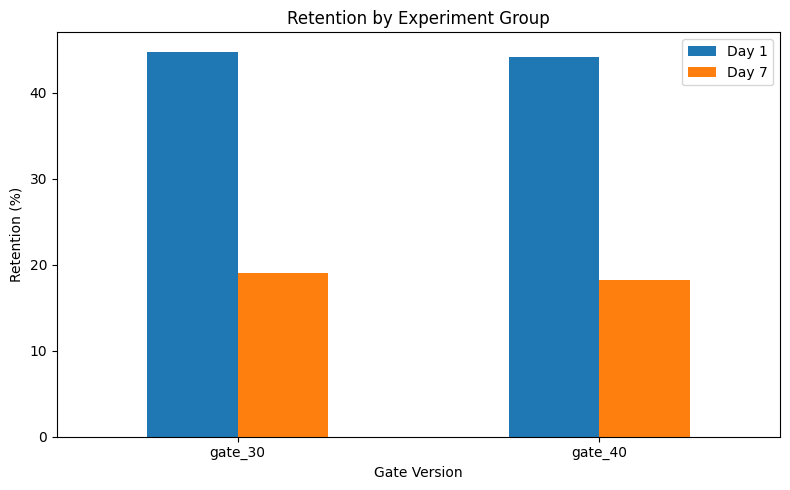

In [36]:
retention_chart = df.groupby("version")[
    ["retention_1", "retention_7"]
].mean() * 100

retention_chart.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Retention by Experiment Group")
plt.xlabel("Gate Version")
plt.ylabel("Retention (%)")
plt.xticks(rotation=0)
plt.legend(["Day 1", "Day 7"])

plt.tight_layout()
plt.show()

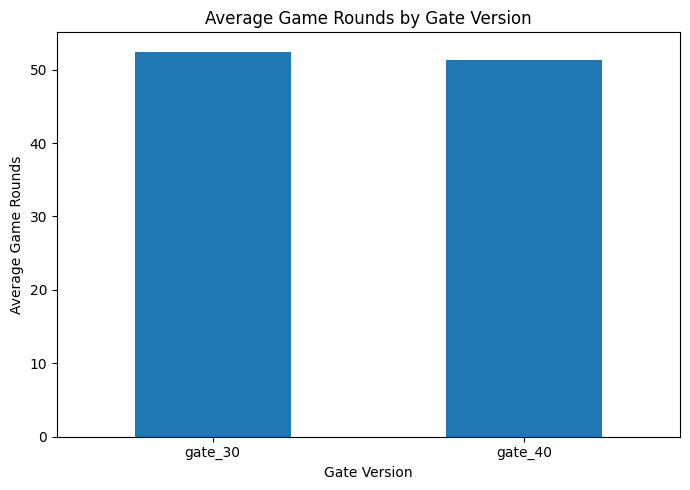

In [37]:
engagement_chart = df.groupby("version")["sum_gamerounds"].mean()

engagement_chart.plot(
    kind="bar",
    figsize=(7, 5)
)

plt.title("Average Game Rounds by Gate Version")
plt.xlabel("Gate Version")
plt.ylabel("Average Game Rounds")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [38]:
segment_analysis

engagement_segment,High,Low,Medium
version,,,
gate_30,13.635347,39.536913,46.827740
gate_40,13.827519,40.264679,45.907802


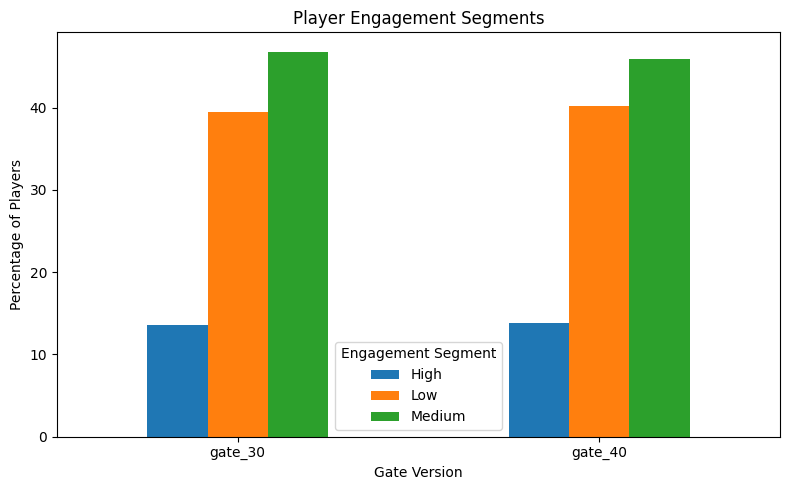

In [39]:
segment_analysis.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Player Engagement Segments")
plt.xlabel("Gate Version")
plt.ylabel("Percentage of Players")
plt.xticks(rotation=0)
plt.legend(title="Engagement Segment")

plt.tight_layout()
plt.show()

In [40]:
comparison = dashboard.copy()

comparison

,version,players,avg_game_rounds,median_game_rounds,day1_retention,day7_retention
0,gate_30,44700,52.46,17.0,44.82,19.02
1,gate_40,45489,51.30,16.0,44.23,18.20


In [41]:
gate30 = dashboard[dashboard["version"] == "gate_30"].iloc[0]
gate40 = dashboard[dashboard["version"] == "gate_40"].iloc[0]

print("========== GATE 40 vs GATE 30 ==========")

print(
    f"Average rounds change: "
    f"{((gate40['avg_game_rounds'] / gate30['avg_game_rounds']) - 1) * 100:.2f}%"
)

print(
    f"Day-1 retention change: "
    f"{gate40['day1_retention'] - gate30['day1_retention']:.2f} percentage points"
)

print(
    f"Day-7 retention change: "
    f"{gate40['day7_retention'] - gate30['day7_retention']:.2f} percentage points"
)

========== GATE 40 vs GATE 30 ==========
Average rounds change: -2.21%
Day-1 retention change: -0.59 percentage points
Day-7 retention change: -0.82 percentage points


In [42]:
print("==========================================")
print("   MOBILE GAME A/B TESTING ANALYSIS")
print("==========================================")

print("\nBUSINESS QUESTION")
print("Does moving the progression gate from Level 30 to Level 40")
print("improve player engagement and retention?")

print("\nKEY FINDINGS")
print("-" * 42)

print("1. Engagement")
print("   Gate 40 had 2.21% lower average game rounds.")

print("2. Day-1 Retention")
print("   Gate 40 was 0.59 percentage points lower.")
print("   Difference was NOT statistically significant (p = 0.0755).")

print("3. Day-7 Retention")
print("   Gate 40 was 0.82 percentage points lower.")
print("   Relative decline: 4.31%.")
print("   Difference WAS statistically significant (p = 0.0016).")

print("\nRECOMMENDATION")
print("-" * 42)
print("Retain the Level-30 gate and conduct follow-up")
print("experiments with alternative progression points.")

   MOBILE GAME A/B TESTING ANALYSIS

BUSINESS QUESTION
Does moving the progression gate from Level 30 to Level 40
improve player engagement and retention?

KEY FINDINGS
------------------------------------------
1. Engagement
   Gate 40 had 2.21% lower average game rounds.
2. Day-1 Retention
   Gate 40 was 0.59 percentage points lower.
   Difference was NOT statistically significant (p = 0.0755).
3. Day-7 Retention
   Gate 40 was 0.82 percentage points lower.
   Relative decline: 4.31%.
   Difference WAS statistically significant (p = 0.0016).

RECOMMENDATION
------------------------------------------
Retain the Level-30 gate and conduct follow-up
experiments with alternative progression points.
